# Axe 1 : Vie personnelle

Dans ce notebook, j'étudie les variables liées aux caractéristiques personnelles des employés afin d'évaluer leur impact sur l'attrition.

Ce notebook a pour objectif :
- d'explorer les variables de l'axe,
- de comparer avec l'attrition
- d'explorer des relations internes à l’axe
- de visualiser
- retenir seulement ce qui ressort clairement
---

## 1. Exploration des variables de l’axe
---

### 1.1 Import des librairies et Chargement 
---

In [ ]:
# import librairies 

import pandas as pd
import pyarrow
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
# chargement du df
df_clean = pd.read_parquet("C:/Users/Kemu/Documents/Formation/Projet Pro Data/2_Projets_Tests/projet-RH_test/data/processed/employees_clean.parquet")
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   string
 2   BusinessTravel            1470 non-null   string
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   string
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   string
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   string
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

### 1.2 Creation du DataFrame vie_perso
---
#### Colonnes incluses dans l'axe "Vie personnelle"

Cet axe regroupe les caractéristiques individuelles :
- âge  
- situation familiale  
- genre  
- niveau d'éducation  et domaines
- mobilité géographique  
donnant un contexte personnel pouvant influencer l'attrition.

In [ ]:
# colonnes vie_perso
col_perso = ['Age', 'DistanceFromHome','Education','EducationField','Gender','MaritalStatus','NumCompaniesWorked']

# creation df_vie_perso
df_vie_perso = df_clean[col_perso + ['Attrition']]
df_vie_perso

#### Création de tranches d'âge

L'âge est une variable continue peu lisible en l'état.  
Pour faciliter l'analyse et observer des tendances plus nettes, je regroupe les employés en classes d'âge cohérentes du point de vue RH :

- **18–25 ans** : début de carrière, forte mobilité
- **26–35 ans** : stabilisation professionnelle, construction familiale
- **36–45 ans** : maturité professionnelle
- **46–55 ans** : employés expérimentés
- **55+ ans** : fin de carrière

Ces tranches permettront d'étudier plus clairement la relation entre âge et attrition.

In [ ]:
# Creation tranche d'age
df_vie_perso["Tranche_Age"] = pd.cut(
    df_vie_perso["Age"],
    bins=[0 , 25, 35, 45, 55, 150],
    labels=["18-25", "26-35", "36-45", "46-55", "+55"],
    ordered=True
)

df_vie_perso["Tranche_Age"].value_counts()

### 1.3  Analyse individuelle des variables 
---

Pour CHAQUE variable,A faire : une analyse comme :

distribution (value_counts, histogramme…)

commentaire en 1–2 phrases


A faire 
→ histogrammes
→ distributions
→ stats simples
→ commentaires
→ compréhension de chaque variable seule

#### 1.3.1 Tranche d’âge et genre
---
Je trie les tranches d'âge selon leur fréquence afin de visualiser rapidement les groupes les plus représentés dans l'entreprise.

In [40]:
#  Répartition par age 

age = df_vie_perso["Tranche_Age"].value_counts(normalize=True).sort_values(ascending=False)*100

df_age = age.reset_index()
df_age.columns = ["Tranche_Age" , 'Pourcentage']
df_age

,Tranche_Age,Pourcentage
0,26-35,41.224490
1,36-45,31.836735
2,46-55,15.374150
3,18-25,8.367347
4,+55,3.197279


Je trie le genre des employées selon leur fréquence.

In [ ]:
# Repartition par genre

genre = df_vie_perso[""]

#### Histogramme des tranches d'âge

Ce graphique montre la répartition des employés selon les tranches d'âge.  
On observe deux groupes majoritaires :

- **26–35 ans**  
- **36–45 ans**

Ils représentent la majorité de la population active de l’entreprise.

Les tranches :

- **18–25 ans** et **46–55 ans** sont moins représentées,  
- tandis que les **55+** sont très minoritaires.


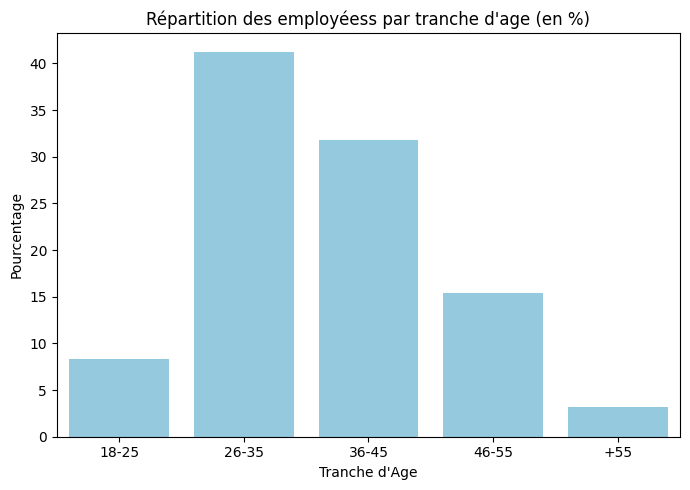

(None,)

In [39]:


plt.figure(figsize=(7,5))

sns.barplot(data=df_age,y="Pourcentage", x="Tranche_Age",color="skyblue")
plt.xlabel("Tranche d'Age")
plt.ylabel("Pourcentage")
plt.title("Répartition des employéess par tranche d'age (en %)")
plt.tight_layout()
plt.show(),

#### 1.3.2 DistanceFromHome
---

#### 1.3.3 Education
---

#### 1.3.4 EducationField
---

#### 1.3.5 Gender
---

#### 1.3.6 MaritalStatus
---

#### 1.3.7 NumCompaniesWorked
---

### comparaisons simples, visualisations basiques, inspection initiale
---

## 2. Attrition — Comparaisons simples
---

### croisements, graphiques, premières observations

## 3. Relations internes à l’axe (corrélations, patterns internes)
----

# 4. Visualisations complémentaires
---

# 5. Résultats clés (3 à 5 observations max)
---
ce que J4 observes

sans aller jusqu’à une conclusion business trop poussée